# Retail Sales Data Engineering & Business Intelligence Project

## Objective
To design and implement an end-to-end data engineering solution for retail sales data, including data ingestion, data cleaning, transformation, data warehouse design, and business intelligence reporting using Power BI.

## Technology Used
- Python
- Pandas
- Google Colab
- Power BI
- DAX
- CSV

In [ ]:
# ============================================
# 1. DATA INGESTION
# ============================================

import pandas as pd
import numpy as np

# Load the raw retail sales dataset
file_path = "/content/retail_sales_raw.csv"

df = pd.read_csv(file_path)

print("Dataset successfully loaded!")
print(f"Number of rows    : {df.shape[0]}")
print(f"Number of columns : {df.shape[1]}")

# Display the first 5 records
df.head()

Dataset successfully loaded!
Number of rows    : 2515
Number of columns : 13


,Order_ID,Order_Date,Customer_ID,Customer_Name,City,Region,Product_Name,Category,Quantity,Unit_Price,Discount,Sales,Profit
0,ORD00001,2024-04-12,C020,Sara Khan,Bhopal,Central,Backpack,Accessories,3,2200,0.10,5940.0,1324.16
1,ORD00002,2024-05-01,C019,Neil Bhat,Indore,West,Study Desk,Furniture,3,7200,0.05,20520.0,6550.38
2,ORD00003,2025-10-25,C003,Rohan Deshmukh,Nashik,West,Office Chair,Furniture,5,9500,0.20,38000.0,2541.79
3,ORD00004,2025-01-20,C001,Aarav Sharma,Mumbai,West,File Organizer,Stationery,2,380,0.10,684.0,177.54
4,ORD00005,2025-07-14,C010,Diya Das,Bhubaneswar,East,File Organizer,Stationery,4,380,0.05,1444.0,423.75


In [ ]:
# ============================================
# 2. DATA PROFILING & QUALITY ASSESSMENT
# ============================================

# Check data types and non-null values
print("DATASET INFORMATION")
print("=" * 50)

df.info()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2515 entries, 0 to 2514
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       2515 non-null   object 
 1   Order_Date     2515 non-null   object 
 2   Customer_ID    2515 non-null   object 
 3   Customer_Name  2515 non-null   object 
 4   City           2507 non-null   object 
 5   Region         2515 non-null   object 
 6   Product_Name   2515 non-null   object 
 7   Category       2515 non-null   object 
 8   Quantity       2515 non-null   int64  
 9   Unit_Price     2515 non-null   int64  
 10  Discount       2507 non-null   float64
 11  Sales          2515 non-null   float64
 12  Profit         2515 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 255.6+ KB


In [ ]:
# Missing value analysis

missing_values = df.isnull().sum()

missing_report = pd.DataFrame({
    "Column": missing_values.index,
    "Missing_Values": missing_values.values,
    "Missing_Percentage": (missing_values.values / len(df) * 100).round(2)
})

missing_report

,Column,Missing_Values,Missing_Percentage
0,Order_ID,0,0.00
1,Order_Date,0,0.00
2,Customer_ID,0,0.00
3,Customer_Name,0,0.00
4,City,8,0.32
5,Region,0,0.00
6,Product_Name,0,0.00
7,Category,0,0.00
8,Quantity,0,0.00
9,Unit_Price,0,0.00


In [ ]:
# Duplicate record analysis

duplicate_count = df.duplicated().sum()

print(f"Total duplicate rows: {duplicate_count}")

Total duplicate rows: 15


In [ ]:
# Check unique category values
print("Unique Category Values:")
print(df["Category"].unique())

print("\nCategory Frequency:")
print(df["Category"].value_counts())

Unique Category Values:
['Accessories' 'Furniture' 'Stationery' 'Electronics' 'Furniture '
 'electronics']

Category Frequency:
Category
Electronics    855
Furniture      678
Stationery     497
Accessories    479
Furniture        3
electronics      3
Name: count, dtype: int64


In [ ]:
# ============================================
# 3. DATA CLEANING
# ============================================

# Create a working copy of the raw dataset
cleaned_df = df.copy()

# 1. Remove duplicate records
before_duplicates = len(cleaned_df)

cleaned_df = cleaned_df.drop_duplicates()

duplicates_removed = before_duplicates - len(cleaned_df)

# 2. Convert Order_Date to proper date format
cleaned_df["Order_Date"] = pd.to_datetime(
    cleaned_df["Order_Date"],
    errors="coerce"
)

# 3. Handle missing City values
cleaned_df["City"] = cleaned_df["City"].fillna("Unknown")

# 4. Handle missing Discount values
cleaned_df["Discount"] = cleaned_df["Discount"].fillna(0)

# 5. Standardize text formatting
cleaned_df["Region"] = cleaned_df["Region"].str.strip().str.title()
cleaned_df["Category"] = cleaned_df["Category"].str.strip().str.title()
cleaned_df["Product_Name"] = cleaned_df["Product_Name"].str.strip()

# Display cleaning summary
print("DATA CLEANING COMPLETED")
print("=" * 50)
print(f"Original rows       : {before_duplicates}")
print(f"Duplicates removed  : {duplicates_removed}")
print(f"Final rows           : {len(cleaned_df)}")

DATA CLEANING COMPLETED
Original rows       : 2515
Duplicates removed  : 15
Final rows           : 2500


In [ ]:
# Verify missing values after cleaning

print("MISSING VALUES AFTER CLEANING")
print("=" * 50)

print(cleaned_df.isnull().sum())

MISSING VALUES AFTER CLEANING
Order_ID         0
Order_Date       0
Customer_ID      0
Customer_Name    0
City             0
Region           0
Product_Name     0
Category         0
Quantity         0
Unit_Price       0
Discount         0
Sales            0
Profit           0
dtype: int64


In [ ]:
# Verify duplicates after cleaning

print("DUPLICATES AFTER CLEANING")
print("=" * 50)

print("Duplicate rows:", cleaned_df.duplicated().sum())

DUPLICATES AFTER CLEANING
Duplicate rows: 0


In [ ]:
# ============================================
# 4. DATA TRANSFORMATION
# ============================================

# Create a copy for the transformed dataset
transformed_df = cleaned_df.copy()

# 1. Calculate Gross Sales
transformed_df["Gross_Sales"] = (
    transformed_df["Quantity"] * transformed_df["Unit_Price"]
)

# 2. Calculate Discount Amount
transformed_df["Discount_Amount"] = (
    transformed_df["Gross_Sales"] * transformed_df["Discount"]
)

# 3. Calculate Profit Margin
transformed_df["Profit_Margin"] = np.where(
    transformed_df["Sales"] != 0,
    transformed_df["Profit"] / transformed_df["Sales"],
    0
)

# 4. Create Year
transformed_df["Year"] = transformed_df["Order_Date"].dt.year

# 5. Create Month Number
transformed_df["Month_Number"] = transformed_df["Order_Date"].dt.month

# 6. Create Month Name
transformed_df["Month"] = transformed_df["Order_Date"].dt.month_name()

# 7. Create Quarter
transformed_df["Quarter"] = (
    "Q" + transformed_df["Order_Date"].dt.quarter.astype(str)
)

# 8. Create Profit Status
transformed_df["Profit_Status"] = np.where(
    transformed_df["Profit"] > 0,
    "Profitable",
    "No Profit"
)

print("DATA TRANSFORMATION COMPLETED")
print("=" * 50)

print(f"Rows    : {transformed_df.shape[0]}")
print(f"Columns : {transformed_df.shape[1]}")

DATA TRANSFORMATION COMPLETED
Rows    : 2500
Columns : 21


In [ ]:
# Display selected transformed fields

transformed_df[
    [
        "Order_ID",
        "Sales",
        "Profit",
        "Gross_Sales",
        "Discount_Amount",
        "Profit_Margin",
        "Year",
        "Month",
        "Quarter",
        "Profit_Status"
    ]
].head()

,Order_ID,Sales,Profit,Gross_Sales,Discount_Amount,Profit_Margin,Year,Month,Quarter,Profit_Status
0,ORD00001,5940.0,1324.16,6600,660.0,0.222923,2024,April,Q2,Profitable
1,ORD00002,20520.0,6550.38,21600,1080.0,0.319219,2024,May,Q2,Profitable
2,ORD00003,38000.0,2541.79,47500,9500.0,0.066889,2025,October,Q4,Profitable
3,ORD00004,684.0,177.54,760,76.0,0.259561,2025,January,Q1,Profitable
4,ORD00005,1444.0,423.75,1520,76.0,0.293456,2025,July,Q3,Profitable


In [ ]:
# Transformation summary

print("TRANSFORMED DATA SUMMARY")
print("=" * 50)

print(f"Total Sales       : ₹{transformed_df['Sales'].sum():,.2f}")
print(f"Total Profit      : ₹{transformed_df['Profit'].sum():,.2f}")
print(f"Total Orders      : {transformed_df['Order_ID'].nunique():,}")
print(f"Total Customers   : {transformed_df['Customer_ID'].nunique():,}")
print(f"Total Quantity    : {transformed_df['Quantity'].sum():,}")
print(
    f"Average Profit Margin : "
    f"{transformed_df['Profit_Margin'].mean() * 100:.2f}%"
)

TRANSFORMED DATA SUMMARY
Total Sales       : ₹82,480,073.50
Total Profit      : ₹21,842,840.44
Total Orders      : 2,500
Total Customers   : 20
Total Quantity    : 7,449
Average Profit Margin : 26.20%


In [ ]:
# ============================================
# 5. DATA WAREHOUSE DESIGN
#    DIMENSION TABLES
# ============================================

# Create Product Dimension

dim_product = (
    transformed_df[
        ["Product_Name", "Category"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

# Create a surrogate Product_ID
dim_product.insert(
    0,
    "Product_ID",
    range(1, len(dim_product) + 1)
)

print("DIM_PRODUCT")
print("=" * 50)
print(f"Rows: {len(dim_product)}")

dim_product.head()

DIM_PRODUCT
Rows: 18


,Product_ID,Product_Name,Category
0,1,Backpack,Accessories
1,2,Study Desk,Furniture
2,3,Office Chair,Furniture
3,4,File Organizer,Stationery
4,5,Notebook Pack,Stationery


In [ ]:
# Create Customer Dimension

dim_customer = (
    transformed_df[
        ["Customer_ID", "Customer_Name"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

print("DIM_CUSTOMER")
print("=" * 50)
print(f"Rows: {len(dim_customer)}")

dim_customer.head()

DIM_CUSTOMER
Rows: 20


,Customer_ID,Customer_Name
0,C020,Sara Khan
1,C019,Neil Bhat
2,C003,Rohan Deshmukh
3,C001,Aarav Sharma
4,C010,Diya Das


In [ ]:
# Create Region Dimension

dim_region = (
    transformed_df[
        ["City", "Region"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

# Create a surrogate Region_ID
dim_region.insert(
    0,
    "Region_ID",
    range(1, len(dim_region) + 1)
)

print("DIM_REGION")
print("=" * 50)
print(f"Rows: {len(dim_region)}")

dim_region.head()

DIM_REGION
Rows: 24


,Region_ID,City,Region
0,1,Bhopal,Central
1,2,Indore,West
2,3,Nashik,West
3,4,Mumbai,West
4,5,Bhubaneswar,East


In [ ]:
# ============================================
# CREATE DATE DIMENSION
# ============================================

dim_date = (
    transformed_df[["Order_Date"]]
    .drop_duplicates()
    .sort_values("Order_Date")
    .reset_index(drop=True)
)

dim_date["Date_ID"] = (
    dim_date["Order_Date"].dt.strftime("%Y%m%d").astype(int)
)

dim_date["Year"] = dim_date["Order_Date"].dt.year
dim_date["Month_Number"] = dim_date["Order_Date"].dt.month
dim_date["Month"] = dim_date["Order_Date"].dt.month_name()
dim_date["Quarter"] = (
    "Q" + dim_date["Order_Date"].dt.quarter.astype(str)
)

dim_date = dim_date[
    ["Date_ID", "Order_Date", "Year",
     "Month_Number", "Month", "Quarter"]
]

print("DIM_DATE CREATED")
print("Total rows:", len(dim_date))

dim_date.head()

DIM_DATE CREATED
Total rows: 698


,Date_ID,Order_Date,Year,Month_Number,Month,Quarter
0,20240101,2024-01-01,2024,1,January,Q1
1,20240102,2024-01-02,2024,1,January,Q1
2,20240103,2024-01-03,2024,1,January,Q1
3,20240105,2024-01-05,2024,1,January,Q1
4,20240106,2024-01-06,2024,1,January,Q1


In [ ]:
# ============================================
# CREATE FACT SALES TABLE
# ============================================

fact_sales = transformed_df.copy()

# Map Product_ID
fact_sales = fact_sales.merge(
    dim_product,
    on=["Product_Name", "Category"],
    how="left"
)

# Map Region_ID
fact_sales = fact_sales.merge(
    dim_region,
    on=["City", "Region"],
    how="left"
)

# Map Date_ID
fact_sales = fact_sales.merge(
    dim_date[["Order_Date", "Date_ID"]],
    on="Order_Date",
    how="left"
)

# Select fact table columns
fact_sales = fact_sales[
    [
        "Order_ID",
        "Date_ID",
        "Product_ID",
        "Customer_ID",
        "Region_ID",
        "Quantity",
        "Unit_Price",
        "Discount",
        "Sales",
        "Profit",
        "Gross_Sales",
        "Discount_Amount",
        "Profit_Margin",
        "Profit_Status"
    ]
]

print("FACT_SALES CREATED")
print("=" * 50)
print("Total transactions:", len(fact_sales))

fact_sales.head()

FACT_SALES CREATED
Total transactions: 2500


,Order_ID,Date_ID,Product_ID,Customer_ID,Region_ID,Quantity,Unit_Price,Discount,Sales,Profit,Gross_Sales,Discount_Amount,Profit_Margin,Profit_Status
0,ORD00001,20240412,1,C020,1,3,2200,0.10,5940.0,1324.16,6600,660.0,0.222923,Profitable
1,ORD00002,20240501,2,C019,2,3,7200,0.05,20520.0,6550.38,21600,1080.0,0.319219,Profitable
2,ORD00003,20251025,3,C003,3,5,9500,0.20,38000.0,2541.79,47500,9500.0,0.066889,Profitable
3,ORD00004,20250120,4,C001,4,2,380,0.10,684.0,177.54,760,76.0,0.259561,Profitable
4,ORD00005,20250714,4,C010,5,4,380,0.05,1444.0,423.75,1520,76.0,0.293456,Profitable


In [ ]:
# Display all warehouse tables

warehouse_tables = {
    "Fact_Sales": fact_sales,
    "Dim_Date": dim_date,
    "Dim_Product": dim_product,
    "Dim_Customer": dim_customer,
    "Dim_Region": dim_region
}

print("DATA WAREHOUSE SUMMARY")
print("=" * 50)

for table_name, table_data in warehouse_tables.items():
    print(f"{table_name}: {table_data.shape[0]} rows, "
          f"{table_data.shape[1]} columns")

DATA WAREHOUSE SUMMARY
Fact_Sales: 2500 rows, 14 columns
Dim_Date: 698 rows, 6 columns
Dim_Product: 18 rows, 3 columns
Dim_Customer: 20 rows, 2 columns
Dim_Region: 24 rows, 3 columns


In [ ]:
# ============================================
# 6. DATA WAREHOUSE VALIDATION
# ============================================

print("DATA WAREHOUSE VALIDATION")
print("=" * 50)

# 1. Check row counts
print("\nROW COUNT CHECK")
print("-" * 30)

print("Fact_Sales :", len(fact_sales))
print("Dim_Date   :", len(dim_date))
print("Dim_Product:", len(dim_product))
print("Dim_Customer:", len(dim_customer))
print("Dim_Region :", len(dim_region))


# 2. Check missing values in fact table
print("\nMISSING VALUE CHECK")
print("-" * 30)

print(
    "Missing values in Fact_Sales:",
    fact_sales.isnull().sum().sum()
)


# 3. Check duplicate transactions
print("\nDUPLICATE TRANSACTION CHECK")
print("-" * 30)

print(
    "Duplicate Order IDs:",
    fact_sales["Order_ID"].duplicated().sum()
)


# 4. Check foreign-key relationships
print("\nFOREIGN KEY VALIDATION")
print("-" * 30)

print(
    "Invalid Product IDs:",
    fact_sales["Product_ID"].isnull().sum()
)

print(
    "Invalid Region IDs:",
    fact_sales["Region_ID"].isnull().sum()
)

print(
    "Invalid Date IDs:",
    fact_sales["Date_ID"].isnull().sum()
)

print(
    "Invalid Customer IDs:",
    (~fact_sales["Customer_ID"].isin(
        dim_customer["Customer_ID"]
    )).sum()
)

DATA WAREHOUSE VALIDATION

ROW COUNT CHECK
------------------------------
Fact_Sales : 2500
Dim_Date   : 698
Dim_Product: 18
Dim_Customer: 20
Dim_Region : 24

MISSING VALUE CHECK
------------------------------
Missing values in Fact_Sales: 0

DUPLICATE TRANSACTION CHECK
------------------------------
Duplicate Order IDs: 0

FOREIGN KEY VALIDATION
------------------------------
Invalid Product IDs: 0
Invalid Region IDs: 0
Invalid Date IDs: 0
Invalid Customer IDs: 0


In [ ]:
# ============================================
# BUSINESS TOTAL VALIDATION
# ============================================

print("BUSINESS METRIC VALIDATION")
print("=" * 50)

print(f"Total Sales   : ₹{fact_sales['Sales'].sum():,.2f}")
print(f"Total Profit  : ₹{fact_sales['Profit'].sum():,.2f}")
print(f"Total Quantity: {fact_sales['Quantity'].sum():,}")
print(f"Total Orders  : {fact_sales['Order_ID'].nunique():,}")
print(f"Customers     : {fact_sales['Customer_ID'].nunique():,}")

BUSINESS METRIC VALIDATION
Total Sales   : ₹82,480,073.50
Total Profit  : ₹21,842,840.44
Total Quantity: 7,449
Total Orders  : 2,500
Customers     : 20


In [ ]:
# ============================================
# 7. EXPORT DATA WAREHOUSE TABLES
# ============================================

output_path = "/content/"

# Export fact table
fact_sales.to_csv(
    output_path + "fact_sales.csv",
    index=False
)

# Export dimension tables
dim_date.to_csv(
    output_path + "dim_date.csv",
    index=False
)

dim_product.to_csv(
    output_path + "dim_product.csv",
    index=False
)

dim_customer.to_csv(
    output_path + "dim_customer.csv",
    index=False
)

dim_region.to_csv(
    output_path + "dim_region.csv",
    index=False
)

# Export final transformed flat dataset as well
transformed_df.to_csv(
    output_path + "retail_sales_transformed.csv",
    index=False
)

print("DATA WAREHOUSE EXPORT COMPLETED")
print("=" * 50)

print("✓ fact_sales.csv")
print("✓ dim_date.csv")
print("✓ dim_product.csv")
print("✓ dim_customer.csv")
print("✓ dim_region.csv")
print("✓ retail_sales_transformed.csv")

DATA WAREHOUSE EXPORT COMPLETED
✓ fact_sales.csv
✓ dim_date.csv
✓ dim_product.csv
✓ dim_customer.csv
✓ dim_region.csv
✓ retail_sales_transformed.csv


In [ ]:
import os

print("EXPORTED FILES")
print("=" * 50)

for file_name in [
    "fact_sales.csv",
    "dim_date.csv",
    "dim_product.csv",
    "dim_customer.csv",
    "dim_region.csv",
    "retail_sales_transformed.csv"
]:
    if os.path.exists("/content/" + file_name):
        print(f"✓ {file_name}")
    else:
        print(f"✗ {file_name} NOT FOUND")

EXPORTED FILES
✓ fact_sales.csv
✓ dim_date.csv
✓ dim_product.csv
✓ dim_customer.csv
✓ dim_region.csv
✓ retail_sales_transformed.csv


# 8. BUSINESS INTELLIGENCE REPORTING

The processed retail sales data was used as the source for the Power BI reporting layer.

The Power BI dashboard provides an interactive view of:

- Total Sales
- Total Profit
- Total Orders
- Total Customers
- Monthly Sales and Profit Trends
- Sales by Region
- Sales by Category
- Profit by Category
- Top 10 Products by Sales

Interactive slicers are provided for:

- Year
- Region
- Category

The dashboard enables users to analyze sales performance and identify important business trends.

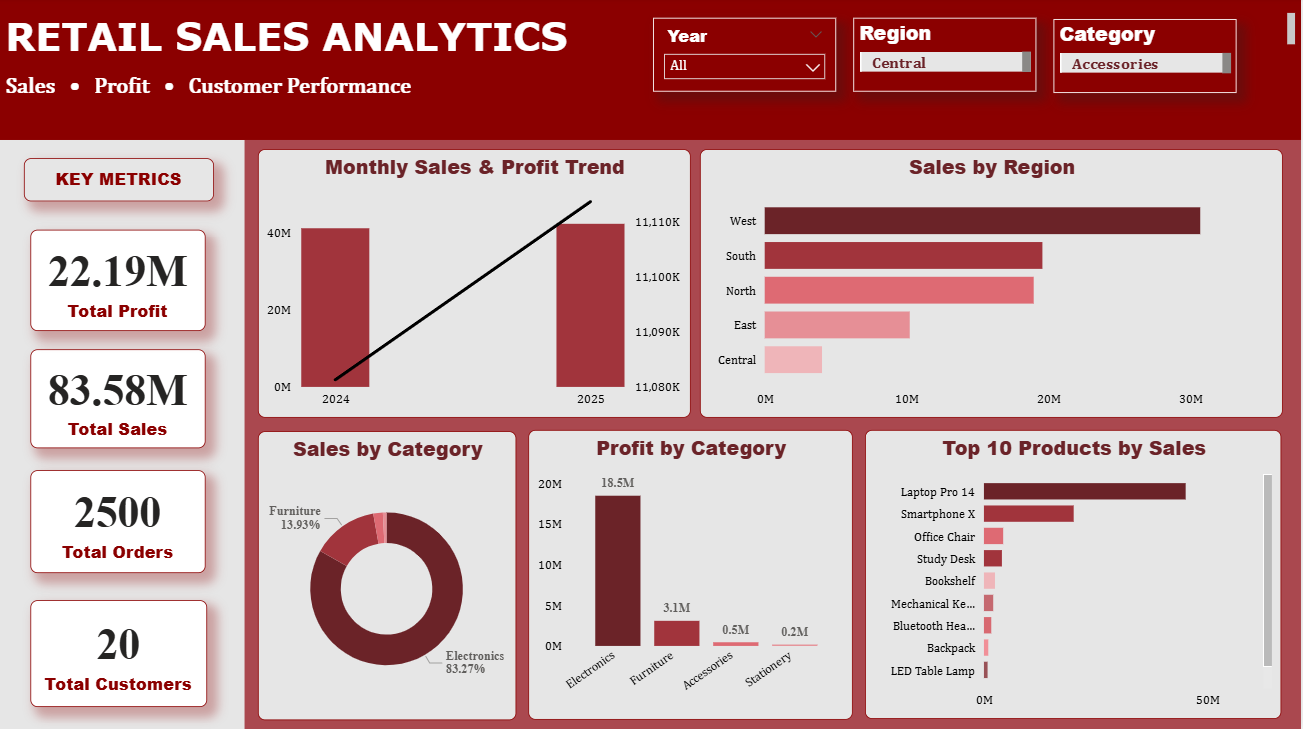

Urvi Sawant | 42